In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Multiset A
A = [2, 2, 2, 4, 6, 6, 6, 6, 8, 8]

A_EV, A_var = np.mean(A), np.var(A)
print(f'A. EV: {A_EV}, Variance: {A_var}')

# Multiset B
B = [5, 5, 5]

B_EV, B_var = np.mean(B), np.var(B)

print(f'B. EV: {B_EV}, Variance: {B_var}')

A. EV: 5.0, Variance: 5.0
B. EV: 5.0, Variance: 0.0


In [3]:
def expected(p):
    """
    Calculates expected value (EV) for betting $100 with American odds -100.

    Args:
        p (float): True probability of success

    Returns:
        float: Calculated EV
    """
    bet = 100
    payout = 200
    return ((payout - bet) * p) + (-bet * (1 - p))

def payout(X):
    """
    Returns total net payout for betting $100 with American odds -100.

    Args:
        X (array_like): Array of binomial betting outcomes

    Returns:
        int: Total resulting net payout
    """
    bet = 100
    payout = 200
    payouts = (X * payout) - 100
    return payouts.sum()

In [4]:
def run_simulation(n_bets, p):
    """
    Simulate betting payouts across many bets, plotting simulated results vs. calculated EV.

    Args:
        n_bets (int): Number of bets (trials)
        p (float): True probability of success
    """
    
    EV = expected(p) * n_bets
    
    X = np.array([], dtype=np.int64)
    running_payout = []
    
    for _ in range(n_bets):
        # Add the results of a single Bernoulli experiment
        X = np.append(X, np.random.binomial(1, p))
        # Append new total payout to running total
        running_payout.append(payout(X))

    # Parse ending profit
    final_profit = running_payout[-1]
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(running_payout, label='Cumulative Profit', color='steelblue', lw=2)
    plt.axhline(y=EV, color='darkorange', linestyle='--', label=f'Expected Value = ${EV:.0f}')
    plt.axhline(y=0, color='gray', linestyle=':', lw=1)

    # Mark ending profit point
    plt.scatter(n_bets - 1, final_profit, color='crimson', s=50, zorder=5, label='Final Profit')
    plt.text(
        n_bets - 1, 
        final_profit, 
        f'  ${final_profit:.0f}', 
        color='crimson', 
        fontsize=10, 
        va='center', 
        fontweight='bold'
    )
    
    plt.title(f'Cumulative Profit vs. Expected Value (p = {p})')
    plt.xlabel('Number of Bets')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.tight_layout()
    plt.show()

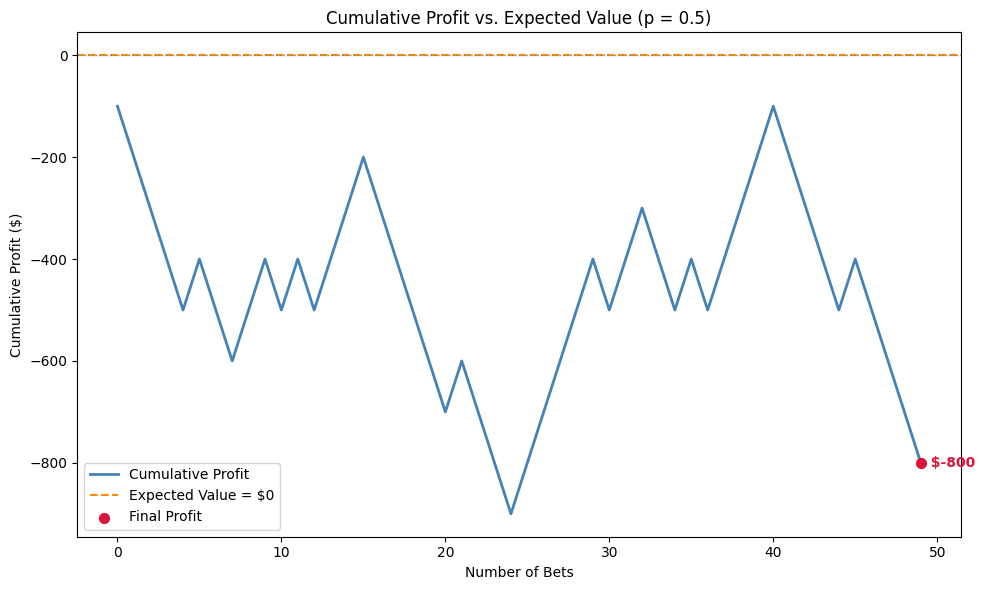

In [5]:
# Set global seed
seed = 133
np.random.seed(seed)

# Fair Game (50 trials)
n_bets = 50
p = 0.5
run_simulation(n_bets, p)

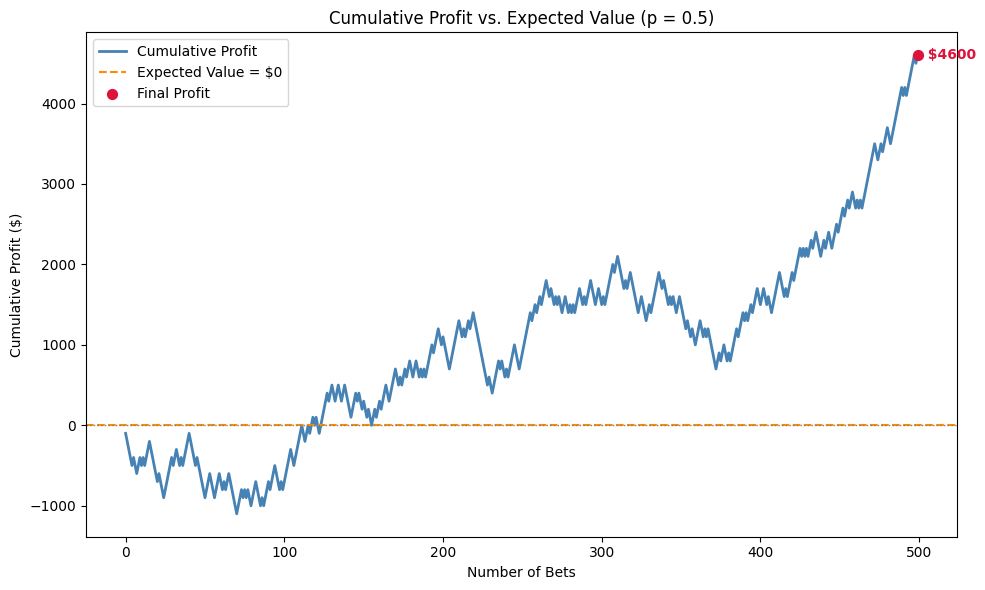

In [6]:
# Reset back to same global seed
np.random.seed(seed)

# Fair Game (500 trials)
n_bets = 500
p = 0.5
run_simulation(n_bets, p)

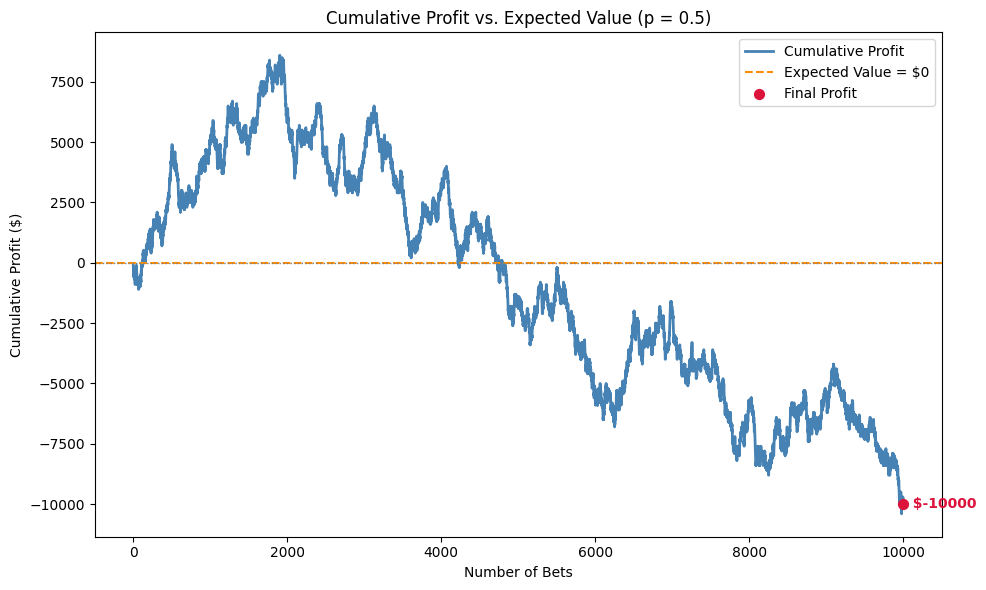

In [7]:
# Reset back to same global seed
np.random.seed(seed)

# Fair Game (10000 trials)
n_bets = 10000
p = 0.5
run_simulation(n_bets, p)

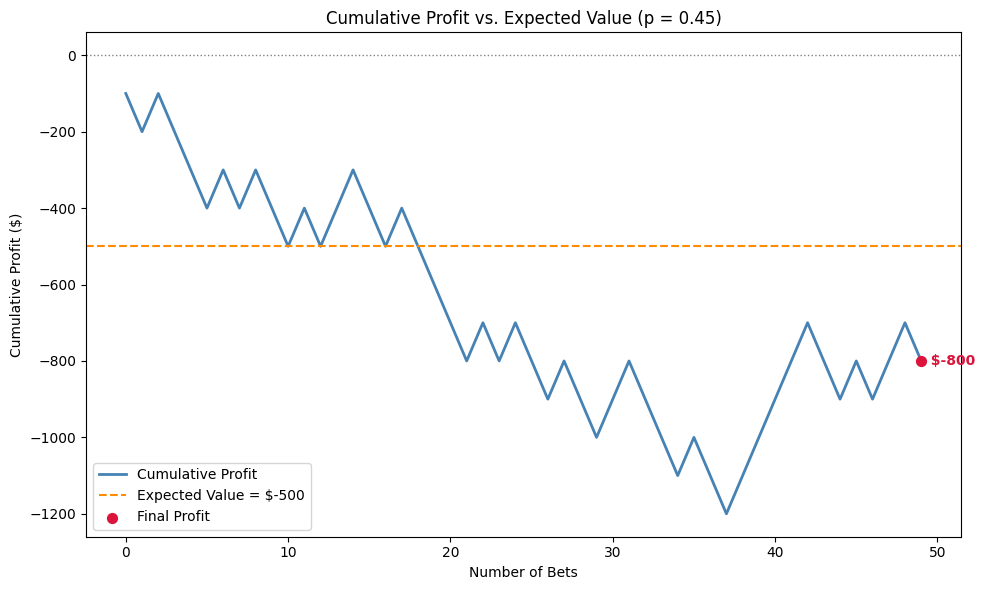

In [8]:
# Negative Edge (50 trials)
n_bets = 50
p = 0.45
run_simulation(n_bets, p)

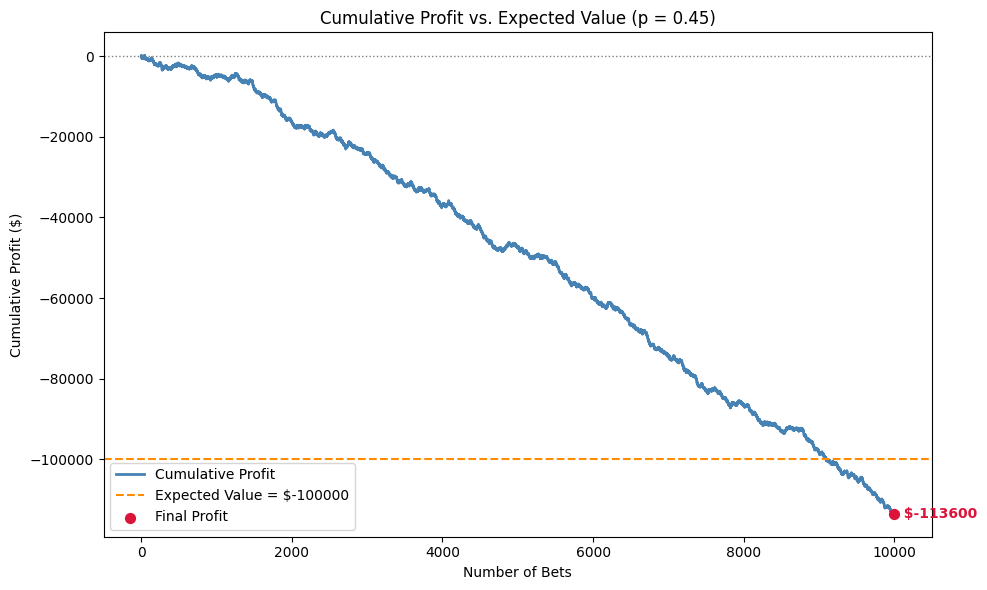

In [9]:
# Negative Edge (10000 trials)
n_bets = 10000
p = 0.45
run_simulation(n_bets, p)

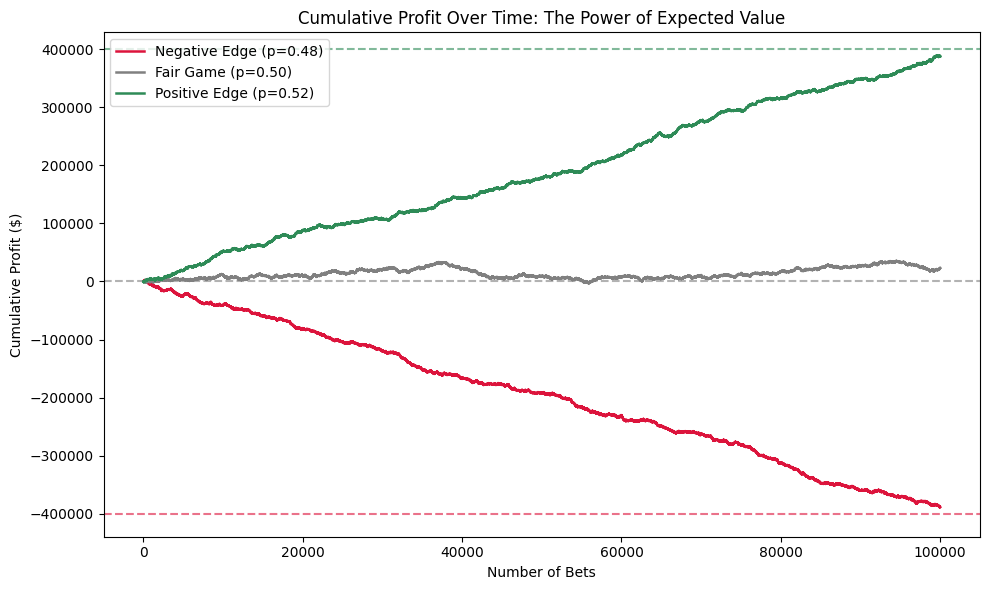

In [10]:
plt.figure(figsize=(10, 6))

n_bets = 100000
for p, color, label in [(0.48, 'crimson', 'Negative Edge (p=0.48)'),
                        (0.50, 'gray', 'Fair Game (p=0.50)'),
                        (0.52, 'seagreen', 'Positive Edge (p=0.52)')]:
    
    EV = expected(p)
    X = np.random.binomial(1, p, n_bets)
    running_payout = np.cumsum((X * 200) - 100)
    
    plt.plot(running_payout, color=color, lw=1.8, label=f'{label}')
    plt.axhline(y=EV * n_bets, color=color, linestyle='--', alpha=0.6)

plt.title("Cumulative Profit Over Time: The Power of Expected Value")
plt.xlabel("Number of Bets")
plt.ylabel("Cumulative Profit ($)")
plt.legend()
plt.tight_layout()
plt.show()